In [1]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task
import statsmodels.api as sm

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [179]:
import numpy as np
import pandas as pd

# Global variances for each variable
var_x1, var_x2, var_x3, var_x4 = 1, 1,10, 1

# Define a function to create each DataFrame with specified correlation structures and generate y as a linear combination
def create_simulation_with_covariance(simulation_num, n=1000):
    # Set up correlation matrices based on required correlation structures
    if simulation_num == 1:
        # x2, x3, x4 are independent
        corr_matrix = np.diag([1, 1, 1])
    elif simulation_num == 2:
        # x2 and x3 weakly correlated, x3 and x4 strongly correlated
        corr_matrix = np.array([
            [1, 0.2, 0.0],
            [0.2, 1, 0.9],
            [0.0, 0.9, 1]
        ])
    elif simulation_num == 3:
        # x4 strongly correlated with both x2 and x3, x2 and x3 weakly correlated
        corr_matrix = np.array([
            [1, 0.3, 0.7],
            [0.3, 1, 0.6],
            [0.7, 0.6, 1]
        ])
    elif simulation_num == 4:
        # x2 and x3 strongly correlated, x4 independent
        corr_matrix = np.array([
            [1, 0.8, 0.0],
            [0.8, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 5:
        # x2, x3, x4 all strongly correlated
        corr_matrix = np.array([
            [1, 0.8, 0.8],
            [0.8, 1, 0.8],
            [0.8, 0.8, 1]
        ])
    elif simulation_num == 6:
        # x2 and x3 weakly correlated
        corr_matrix = np.array([
            [1, 0.2, 0.0],
            [0.2, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 7:
        # x2 and x3 strongly correlated
        corr_matrix = np.array([
            [1, 0.8, 0.0],
            [0.8, 1, 0.0],
            [0.0, 0.0, 1]
        ])
    elif simulation_num == 8:
        # Independent variables for generating x2, x3, x4
        corr_matrix = np.diag([1, 1, 1])
    else:
        raise ValueError("Simulation number must be between 1 and 8")

    # Generate covariance matrix from variances and correlation matrix
    std_devs = np.sqrt([var_x2, var_x3, var_x4])
    cov_matrix = np.outer(std_devs, std_devs) * corr_matrix

    # Generate x2, x3, x4 based on the specified covariance structure
    mean = np.zeros(3)
    x2_x3_x4 = np.random.multivariate_normal(mean, cov_matrix, n)
    x2, x3, x4 = x2_x3_x4[:, 0], x2_x3_x4[:, 1], x2_x3_x4[:, 2]

    # Generate x1 based on different formulas depending on the simulation number
    if simulation_num in [1, 2, 3, 4, 5]:
        x1 = 1.5 * x2 + 2 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
    elif simulation_num == 6:
        x1 = 2 * x2 + 3 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
        x4 = -1 * x2 + 1.5 * x3 + np.random.normal(0, np.sqrt(var_x4), n)
    elif simulation_num == 7:
        x1 = 2 * x2 + 3 * x3 + np.random.normal(0, np.sqrt(var_x1), n)
        x4 = -1 * x2 + 1.5 * x3 + np.random.normal(0, np.sqrt(var_x4), n)
    elif simulation_num == 8:
        x1 = 1.5 * x2 + 2 * x3 - 0.5 * x4 + np.random.normal(0, np.sqrt(var_x1), n)
    
    # Generate y as a linear combination of x1, x2, x3, x4 plus noise
    y = 1.2 * x1 + 0.8 * x2 - 1.5 * x3 + 2.0 * x4 + np.random.normal(0, 1, n)
    
    # Create DataFrame
    df = pd.DataFrame({ 'y': y, 'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4})
    return df

# Generate DataFrames for each simulation
simulations = {}
for i in range(1, 9):
    simulations[f'simulation{i}'] = create_simulation_with_covariance(i)
    filename_3ed = "METHOD_MULTICOLLINEAR_"+str(i)+".xlsx"
    



In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def simulate_data(n, beta, sigma, sigmas, correlation_structure=None, nonlinear=False):
    # Define correlation matrix based on the specified structure
    p = len(sigmas)  # number of predictors
    if correlation_structure == "0_correlation":
        rho_matrix = np.full((p, p), 0)
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "0.5_correlation":
        rho_matrix = np.full((p, p), 0.5)
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "specific_structure":
        rho_matrix = np.zeros((p, p))
        rho_matrix[0, 1] = rho_matrix[1, 0] = 0.7
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "x4_independent":
        rho_matrix = 0.7 ** np.abs(np.subtract.outer(np.arange(p - 1), np.arange(p - 1)))
        rho_matrix = np.pad(rho_matrix, ((0, 1), (0, 1)), mode='constant')
        np.fill_diagonal(rho_matrix, 1.0)
    elif correlation_structure == "two_strong_groups":
        rho_matrix = np.array([
            [1.0, 0.9, 0.0, 0.0],
            [0.9, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.9],
            [0.0, 0.0, 0.9, 1.0]
        ])
    elif correlation_structure == "one_strong_groups":
        rho_matrix = np.array([
            [1.0, 0.8, 0.0, 0.0],
            [0.8, 1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])
    else:
        rho_matrix = 0.9 ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))

    # Calculate covariance matrix using: cov(X_i, X_j) = rho * sigma_i * sigma_j
    cov_matrix = np.outer(sigmas, sigmas) * rho_matrix

    # Generate predictor variables X from a multivariate normal distribution
    X = np.random.multivariate_normal(mean=np.zeros(p), cov=cov_matrix, size=n)

    # Generate noise epsilon
    epsilon = np.random.normal(0, sigma, size=n)

    # Generate response variable y using the specified formula
    if nonlinear:
        y = X[:, 0]**2 + 2 * X[:, 1] + 2 * X[:, 2] + 1.5 * X[:, 3] + epsilon
    else:
        y = X @ beta + epsilon
    
    return X, y

# Simulation settings
n = 2000  # Number of samples
sigmas = np.array([0.5, 1.0, 1.0, 1.0])  # Standard deviations for each predictor

# Define simulations with different beta and sigma values
simulations = [
    {"beta": np.array([3, 2, 1, 0]), "sigma": 1},  # Simulation 1
    {"beta": np.array([3, 2, 1, 0]), "sigma": 1},  # Simulation 2
    {"beta": np.array([3, 0, 0, 2]), "sigma": 1},  # Simulation 3
    {"beta": np.array([0.7, 0.7, 0.7, 0.7]), "sigma": 1},  # Simulation 4
    {"beta": np.array([0, 2, 0, 2]), "sigma": 1},  # Simulation 5
    {"beta": np.array([3, 2, 0, 0]), "sigma": 1},  # Simulation 6
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 1},  # Simulation 7
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 1},  # Simulation 8
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 1},  # Simulation 9
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 1, "nonlinear": True},  # Simulation 10 (non-linear)
    {"beta": np.array([1, 2, 2, 1.5]), "sigma": 1, "nonlinear": True}   # Simulation 11 (non-linear)
]

# Run each simulation and store each in a separate DataFrame
simulation_dfs = {}
for i, sim in enumerate(simulations, 1):
    nonlinear = sim.get("nonlinear", False)
    if i == 1:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="0_correlation", nonlinear=nonlinear)
    elif i == 5:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="0.5_correlation", nonlinear=nonlinear)
    elif i == 6:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="specific_structure", nonlinear=nonlinear)
    elif i == 7:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="x4_independent", nonlinear=nonlinear)
    elif i == 8:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="two_strong_groups", nonlinear=nonlinear)
    elif i == 9:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, correlation_structure="one_strong_groups", nonlinear=nonlinear)
    else:
        X, y = simulate_data(n, sim["beta"], sim["sigma"], sigmas, nonlinear=nonlinear)

    # Store each DataFrame in a dictionary with the name "simulationX"
    sim_df = pd.DataFrame(np.column_stack([y, X]), columns=['y', 'x1', 'x2', 'x3', 'x4'])
    simulation_dfs[f'simulation{i}'] = sim_df
    filename_2ed = "METHOD_DIFF_FUN_"+str(i)+".xlsx"
    #simulation_dfs[f'simulation{i}'].to_excel(filename_2ed, index=False)

# Read simulation9 data for testing purposes
simulation9_data = simulation_dfs['simulation9']
print(simulation9_data)



             y        x1        x2        x3        x4
0    -2.193998 -0.241347 -0.679274 -0.066586 -0.296116
1     3.443812 -0.123726 -0.553223  1.906320  0.286130
2    -5.637265 -0.369039 -1.956528  0.489523 -1.811744
3    -3.454034  0.595419  0.950717 -1.052472 -0.974660
4    -9.695022 -1.073000 -2.132766 -1.613795 -0.878055
...        ...       ...       ...       ...       ...
1995 -6.698541 -1.195955 -1.137363 -1.433656 -1.455052
1996 -7.374548 -0.308256 -1.356957 -1.236251 -0.806907
1997 -1.597101 -0.591141 -0.169150 -0.398896  0.284347
1998  4.633479  0.105999  0.882009  2.669701 -1.890358
1999  0.908856  0.500695  0.025105  0.120758  0.208572

[2000 rows x 5 columns]


In [209]:
#df = pd.read_excel("METHOD_MULTICOLLINEAR_7.xlsx")  # 默认读取第一个工作表
df=simulation_dfs['simulation2']
df = df.head(30)
x = df[['x1','x2','x3',"x4"]] 
y=df["y"]
X_with_intercept = sm.add_constant(x)
model = sm.OLS(y, X_with_intercept)
results = model.fit()
# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

# 打印 RMSE
print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     162.7
Date:                Wed, 26 Feb 2025   Prob (F-statistic):           1.65e-17
Time:                        13:00:51   Log-Likelihood:                -39.474
No. Observations:                  30   AIC:                             88.95
Df Residuals:                      25   BIC:                             95.95
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0810      0.184     -0.439      0.6

In [205]:
import numpy as np
from numpy.linalg import inv
from scipy.stats import t

# 模拟带有多重共线性的数据
def simulate_data(n, beta, rho):
    """
    模型: y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + ε
    为引入多重共线性，通过公共因子构造相关解释变量。
    """
    x_star = np.random.randn(n, len(beta) - 1)
    common = np.random.randn(n, 1)
    X_no_intercept = np.sqrt(1 - rho**2) * x_star + rho * common
    X = np.hstack((np.ones((n, 1)), X_no_intercept))
    sigma = 1.0
    noise = sigma * np.random.randn(n)
    y = X.dot(beta) + noise
    return X, y

# 贝叶斯回归（闭式解）
def bayesian_regression(X, y, theta0, Q0, v0, S0_sq):
    """
    输入：
      X       : 设计矩阵 (n×k)
      y       : 因变量
      theta0  : 先验均值 (k×1)
      Q0      : 先验协方差矩阵（未缩放），对应 θ|h ~ N(θ0, h⁻¹ Q0)
      v0      : 先验自由度（Gamma 分布参数）
      S0_sq   : 先验尺度参数（先验方差的平均值）
      
    输出：
      theta_star : 后验均值
      Q_star     : 后验协方差（在 h 下的缩放矩阵）
      v_star     : 后验自由度（n+v0）
      S_star_sq  : 后验尺度（误差方差）
      theta_hat  : OLS 估计（作为比较）
    """
    n = X.shape[0]
    XtX = X.T.dot(X)
    theta_hat = inv(XtX).dot(X.T).dot(y)
    
    Q0_inv = inv(Q0)
    Q_star = inv(Q0_inv + XtX)
    theta_star = Q_star.dot(Q0_inv.dot(theta0) + XtX.dot(theta_hat))
    
    v_star = n + v0
    SSE = np.sum((y - X.dot(theta_hat))**2)
    temp = theta_hat - theta0
    term = temp.T.dot(inv(Q0 + inv(XtX))).dot(temp)
    S_star_sq = (v0 * S0_sq + SSE + term) / v_star
    
    return theta_star, Q_star, v_star, S_star_sq, theta_hat

# 示例运行
np.random.seed(42)

X=X_with_intercept

# 先验设定（参考论文中的先验规格）
theta0 = np.array([1, 1.47,0.19, -1.9,1.88])
Q0 = np.diag([0.15, 0.1, 0.3, 0.44,0.1])  # 注意第二个变量的方差设定较小，体现了强先验信息
v0 = 5
S0_sq = 1.5

# 贝叶斯回归
theta_star, Q_star, v_star, S_star_sq, theta_hat = bayesian_regression(X, y, theta0, Q0, v0, S0_sq)

print("OLS 估计:", theta_hat)
print("贝叶斯后验均值:", theta_star)
print("后验自由度:", v_star)
print("后验尺度（方差）:", S_star_sq)

# ----------------------------
# 计算贝叶斯方法下的标准误和可信区间（多元 t 分布）
alpha = 0.05
t_val_bayes = t.ppf(1 - alpha / 2, df=v_star)
bayes_results = []
print("\n【贝叶斯方法】")
for i in range(len(theta_star)):
    se_bayes = np.sqrt(S_star_sq * Q_star[i, i])
    lower_bayes = theta_star[i] - t_val_bayes * se_bayes
    upper_bayes = theta_star[i] + t_val_bayes * se_bayes
    bayes_results.append((theta_star[i], se_bayes, lower_bayes, upper_bayes))
    print(f"参数 {i}: 后验均值 = {theta_star[i]:.4f}, 标准误 = {se_bayes:.4f}, 95% 可信区间 = ({lower_bayes:.4f}, {upper_bayes:.4f})")

# ----------------------------
# 计算 OLS 方法下的标准误和置信区间
n, k = X.shape
s2 = np.sum((y - X.dot(theta_hat))**2) / (n - k)
cov_ols = inv(X.T.dot(X))
ols_se = np.sqrt(s2 * np.diag(cov_ols))
t_val_ols = t.ppf(1 - alpha / 2, df=n - k)
ols_results = []
print("\n【OLS 方法】")
for i in range(len(theta_hat)):
    lower_ols = theta_hat[i] - t_val_ols * ols_se[i]
    upper_ols = theta_hat[i] + t_val_ols * ols_se[i]
    ols_results.append((theta_hat[i], ols_se[i], lower_ols, upper_ols))
    print(f"参数 {i}: OLS 估计 = {theta_hat[i]:.4f}, 标准误 = {ols_se[i]:.4f}, 95% 置信区间 = ({lower_ols:.4f}, {upper_ols:.4f})")
# 计算均方误差（MSE），以评估两种方法的估计精度
MSE_bayes = np.mean((theta_star - theta_hat)**2)
MSE_ols = np.mean((theta_hat - theta_hat)**2)


OLS 估计: [-0.2903478   1.39364234  0.1418557  -1.91349056  1.88081851]
贝叶斯后验均值: [-0.12688742  1.39508508  0.19320618 -1.94314113  1.89180683]
后验自由度: 55
后验尺度（方差）: 1.1402028538962166

【贝叶斯方法】
参数 0: 后验均值 = -0.1269, 标准误 = 0.1469, 95% 可信区间 = (-0.4212, 0.1675)
参数 1: 后验均值 = 1.3951, 标准误 = 0.1132, 95% 可信区间 = (1.1682, 1.6220)
参数 2: 后验均值 = 0.1932, 标准误 = 0.3094, 95% 可信区间 = (-0.4269, 0.8133)
参数 3: 后验均值 = -1.9431, 标准误 = 0.3707, 95% 可信区间 = (-2.6860, -1.2002)
参数 4: 后验均值 = 1.8918, 标准误 = 0.1289, 95% 可信区间 = (1.6334, 2.1502)

【OLS 方法】
参数 0: OLS 估计 = -0.2903, 标准误 = 0.1489, 95% 置信区间 = (-0.5903, 0.0096)
参数 1: OLS 估计 = 1.3936, 标准误 = 0.1471, 95% 置信区间 = (1.0973, 1.6899)
参数 2: OLS 估计 = 0.1419, 标准误 = 0.3897, 95% 置信区间 = (-0.6430, 0.9267)
参数 3: OLS 估计 = -1.9135, 标准误 = 0.4666, 95% 置信区间 = (-2.8533, -0.9737)
参数 4: OLS 估计 = 1.8808, 标准误 = 0.1420, 95% 置信区间 = (1.5948, 2.1669)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [p, eta, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 24 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


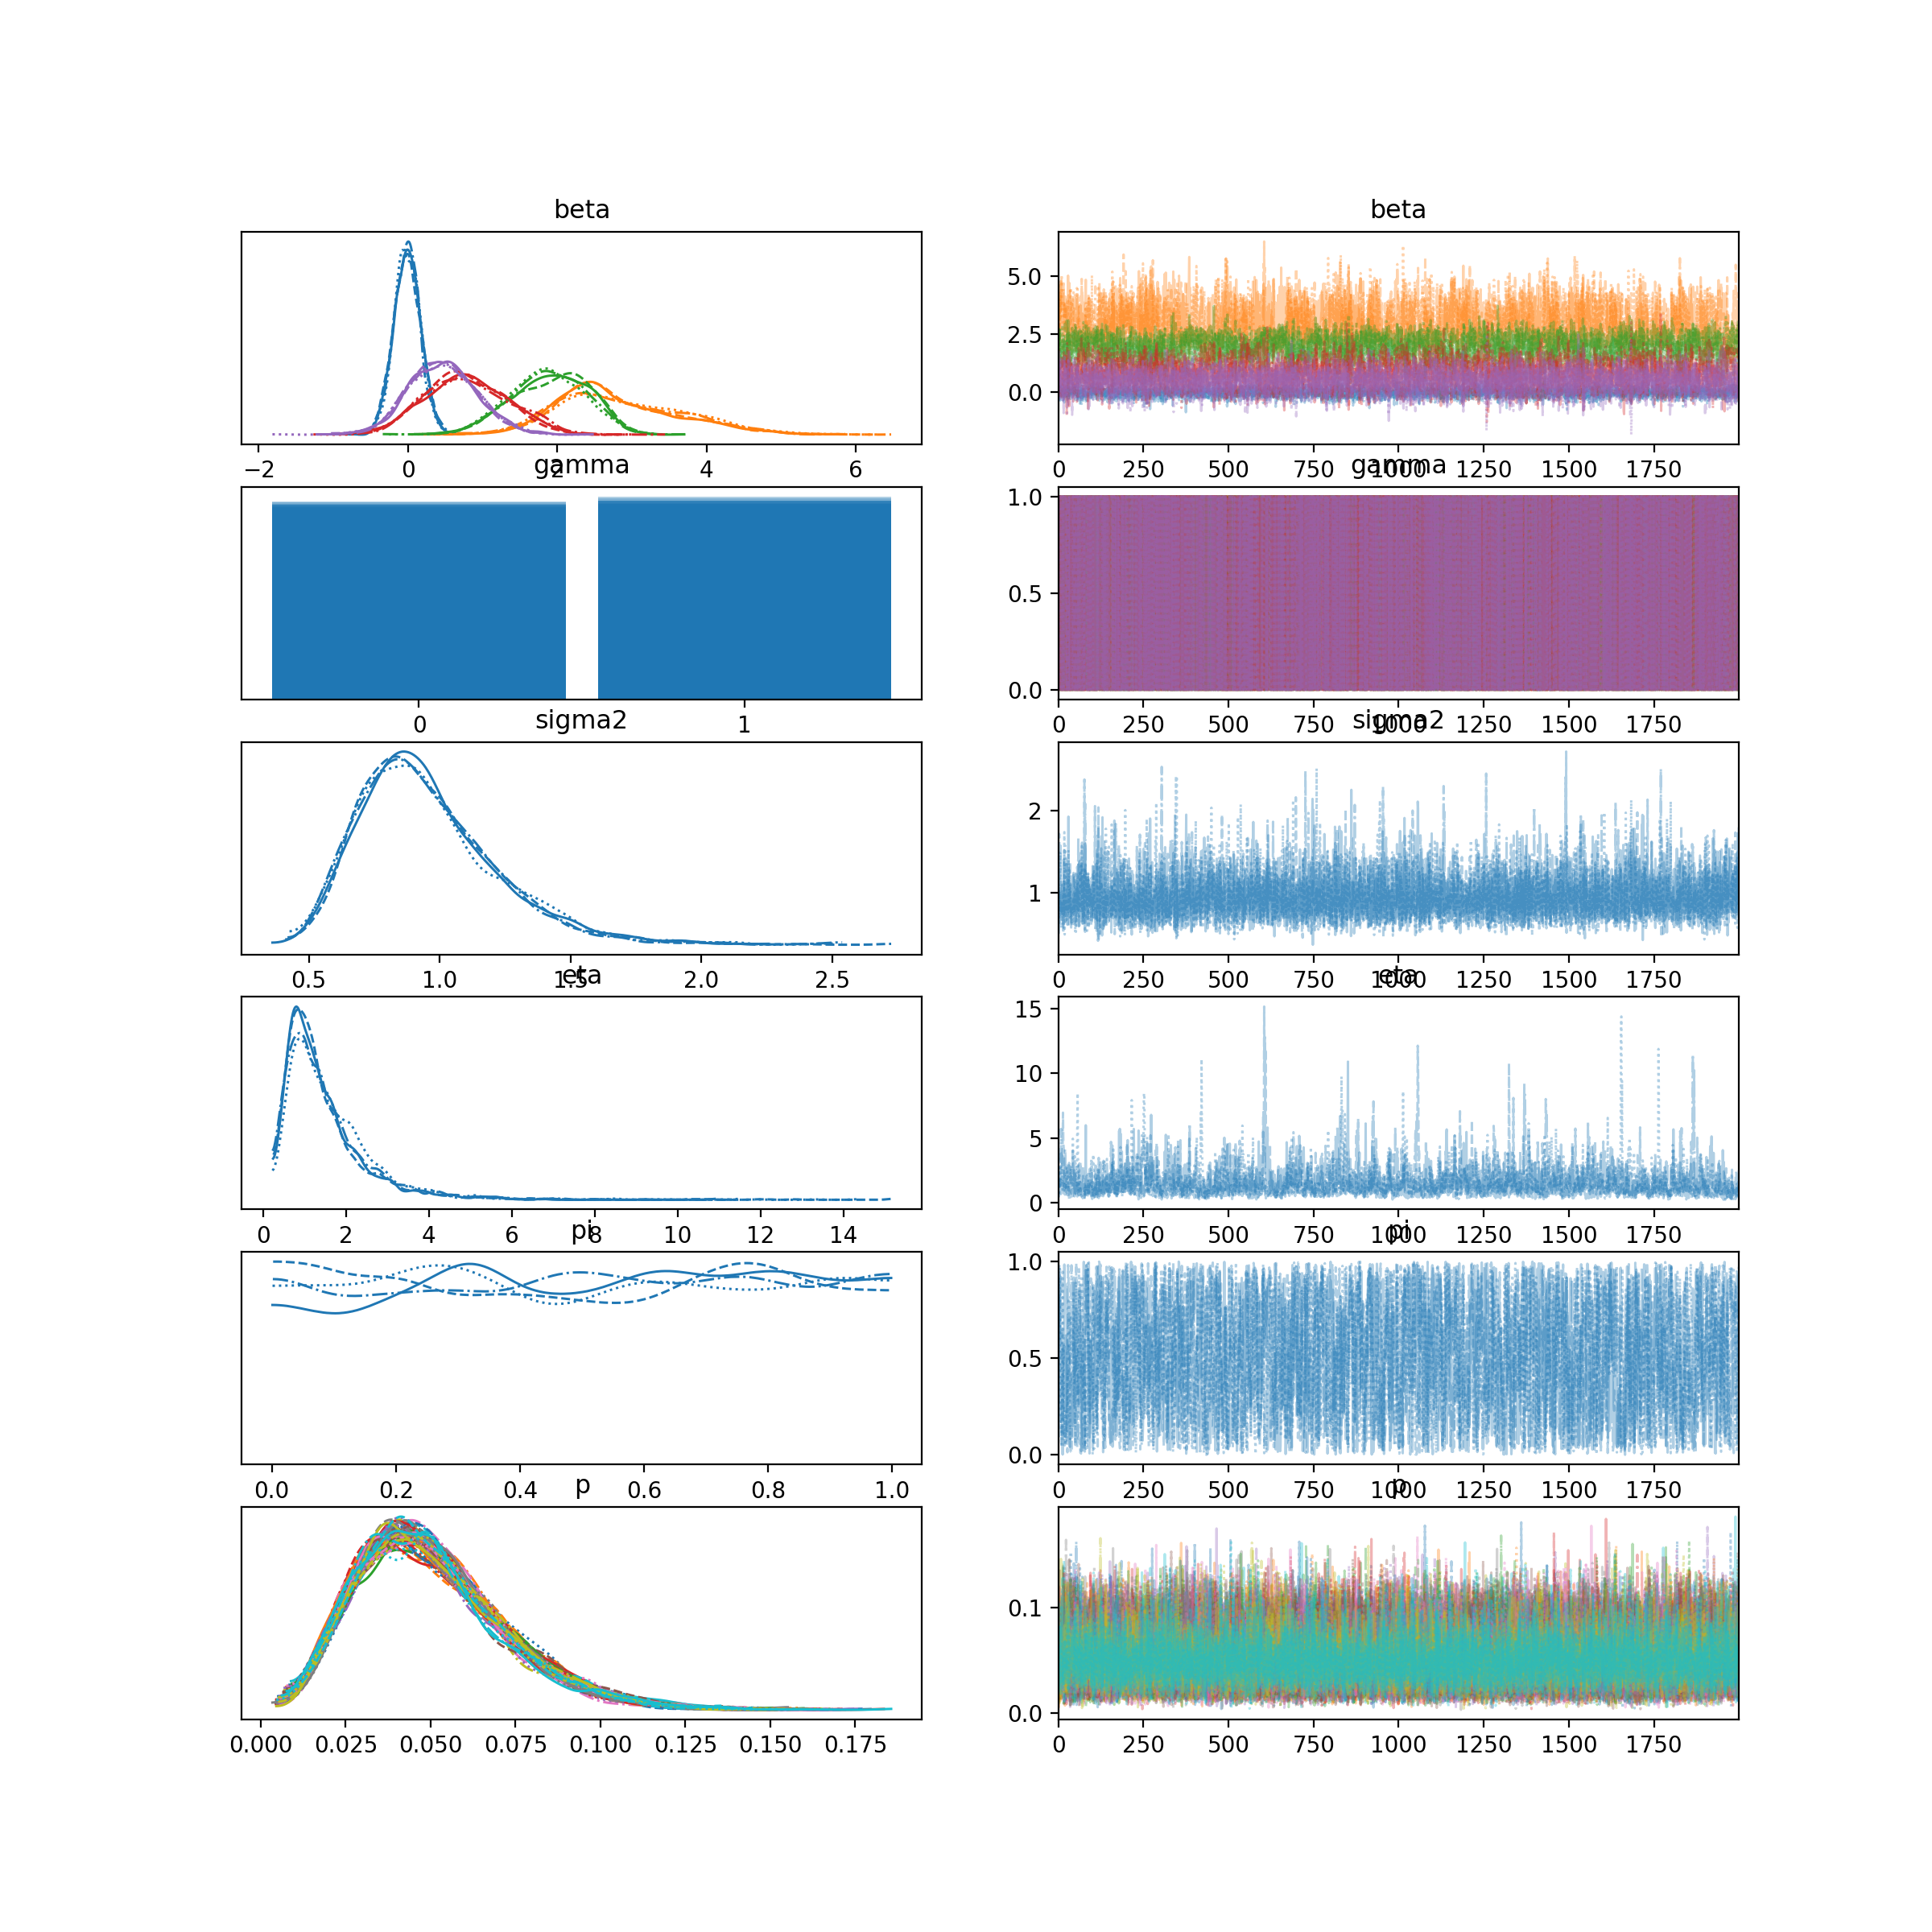

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -0.013  0.180  -0.350    0.329      0.002    0.002    6716.0   
beta[1]   2.823  0.842   1.410    4.468      0.030    0.021     830.0   
beta[2]   1.890  0.514   0.952    2.803      0.020    0.014     658.0   
beta[3]   0.781  0.552  -0.205    1.826      0.014    0.012    1557.0   
beta[4]   0.458  0.454  -0.367    1.324      0.008    0.006    3214.0   
gamma[0]  0.507  0.500   0.000    1.000      0.008    0.006    3491.0   
gamma[1]  0.506  0.500   0.000    1.000      0.009    0.006    3252.0   
gamma[2]  0.504  0.500   0.000    1.000      0.009    0.006    3102.0   
gamma[3]  0.505  0.500   0.000    1.000      0.009    0.006    3272.0   
gamma[4]  0.501  0.500   0.000    1.000      0.008    0.006    3673.0   
sigma2    0.956  0.271   0.521    1.455      0.004    0.003    6315.0   
eta       1.525  1.104   0.269    3.306      0.038    0.027     539.0   
pi        0.504  0.289   0.035    0.971      0.007 

In [219]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 2000  # Number of samples
D = 5  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    #alpha = pm.HalfNormal("alpha", sigma=5.0)  # Dirichlet prior concentration parameter
    alpha=5
    p = pm.Dirichlet("p", a=pm.math.ones(20) * alpha, shape=20)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=5)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=3, beta=0.5)  # Variance for beta_m
    #mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=0, sigma=pm.math.sqrt(eta), shape=20)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi=pm.Uniform("pi",lower=0, upper=1)
    #pi = pm.Beta("pi", alpha=2, beta=2)  # Probability of gamma=1
    #gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    #rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    #gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=3, beta=0.5)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta )  # Predicted mean
    y_obs = pm.Normal("y_obs", mu=mu, sigma=pm.math.sqrt(sigma2), observed=y)

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma","sigma2", "eta","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary)

az.plot_trace(trace, var_names=["beta", "gamma","sigma2", "eta","pi"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi"])
print(summary)

<IPython.core.display.Javascript object>


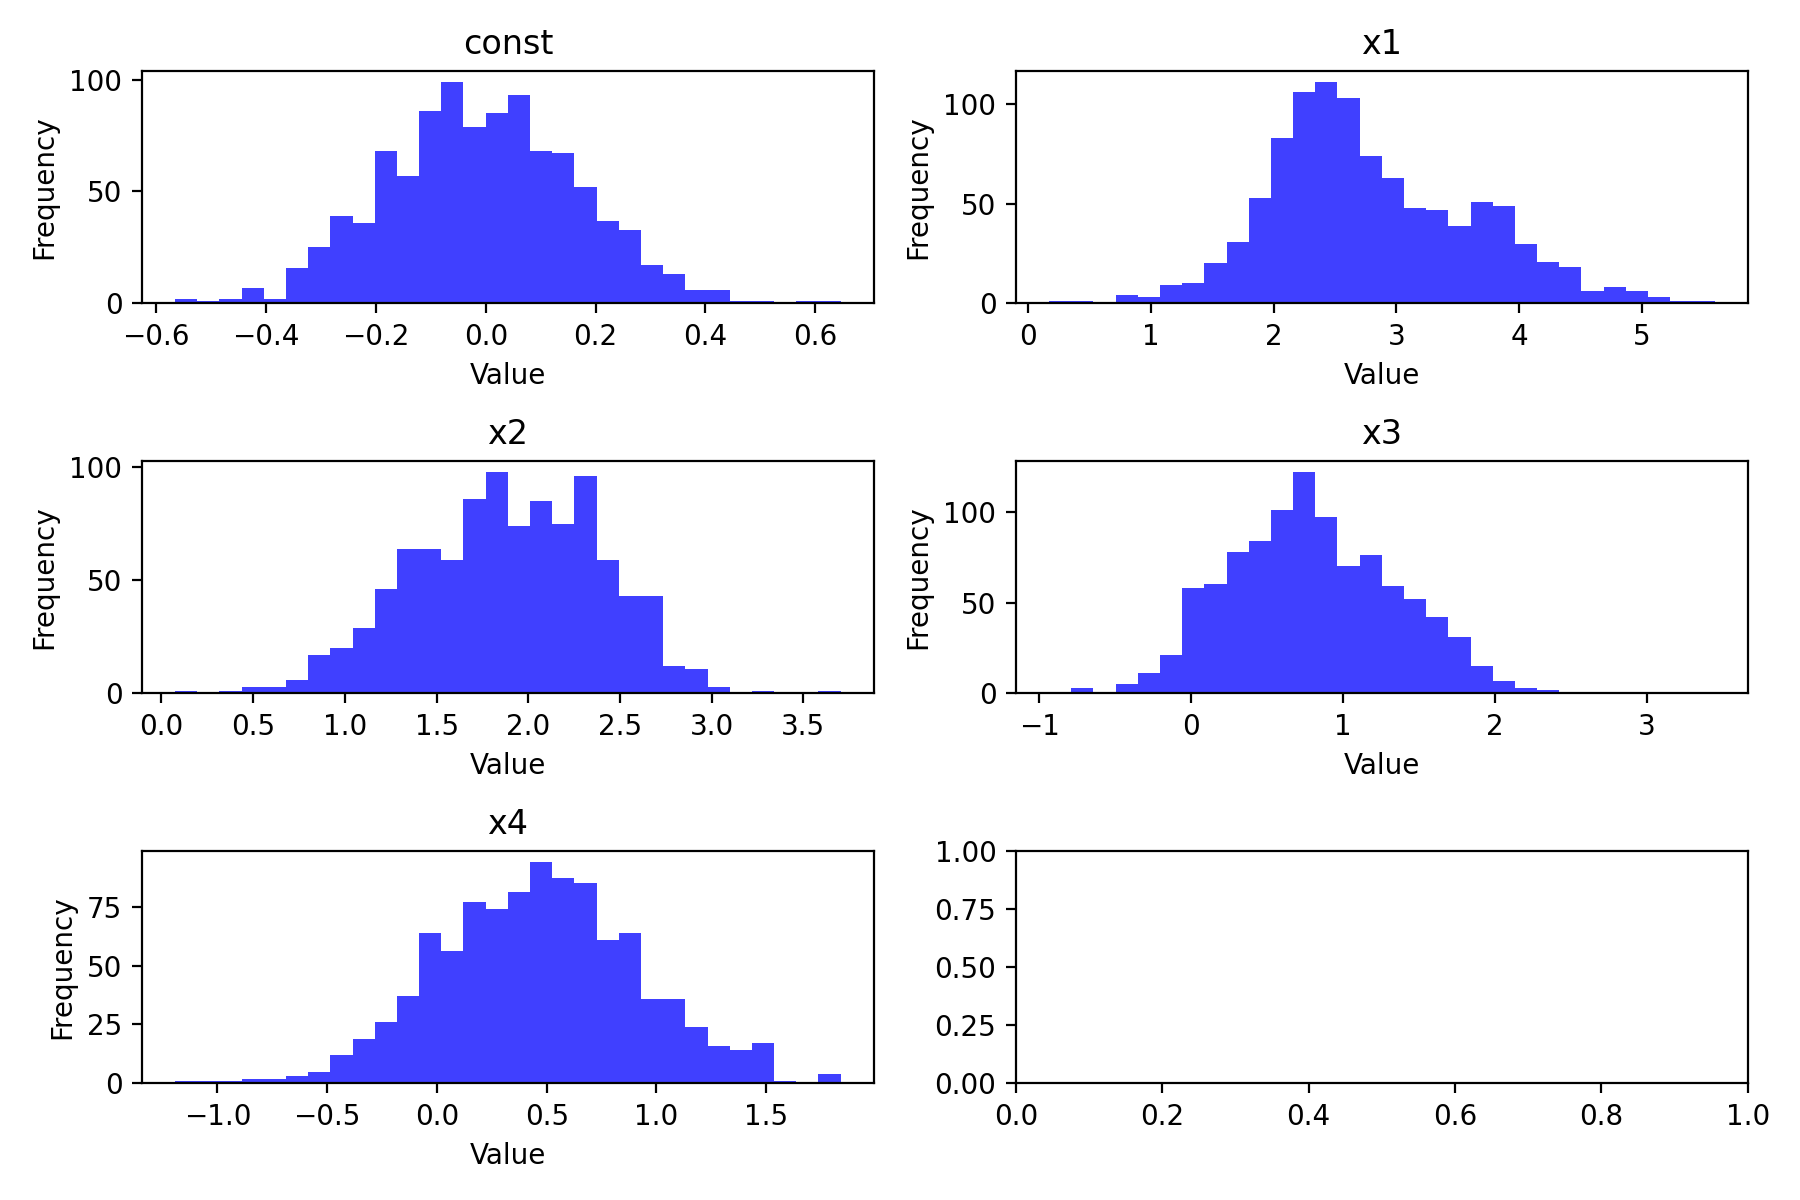

[0.472 0.473 0.488 0.485 0.482]
[-0.0081624   2.79138949  1.88661859  0.79481001  0.46423778]
S_new 90% 置信区间: 
Lower Bound: [-0.28940994  1.65388509  1.04054789 -0.04577332 -0.27092182]
Upper Bound: [0.27720957 4.2774653  2.67904423 1.71883256 1.24925682]
1000 samples' R² values=: 0.6927
1000 samples' RMSE values: 2.5993


In [220]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 6))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)

S_lower = np.percentile(S_new, 5, axis=0)
S_upper = np.percentile(S_new, 95, axis=0)

print(f"S_new 90% 置信区间: \nLower Bound: {S_lower}\nUpper Bound: {S_upper}")

#print(beta_new_look)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")
# 计算 RMSE
RMSE = np.sqrt(np.mean((pred_mean - y) ** 2))
print(f"1000 samples' RMSE values: {RMSE:.4f}")


In [94]:
import numpy as np
from collections import defaultdict

# 转换 beta_new_look 为 NumPy 数组，形状为 (num_samples, num_coeffs)
beta_new_look_arr = np.array(beta_new_look)  # (1000, num_coeffs)
num_samples, num_coeffs = beta_new_look_arr.shape

# 统计变量组合的出现次数
group_counts = defaultdict(int)

for sample in beta_new_look_arr:
    # 创建一个字典来存储哪些变量属于同一个组（忽略具体组号）
    group_dict = defaultdict(list)
    for coef_idx, group_id in enumerate(sample):
        group_dict[group_id].append(coef_idx)

    # 只存储有两个或以上变量的组（即真正形成组合的）
    for group_members in group_dict.values():
        if len(group_members) > 1:
            group_tuple = tuple(sorted(group_members))  # 保持一致性
            group_counts[group_tuple] += 1

# 计算每个组合的概率
group_probs = {group: count / num_samples for group, count in group_counts.items()}

# 按概率降序排序
sorted_groups = sorted(group_probs.items(), key=lambda x: x[1], reverse=True)

# 输出结果
print("变量组合 & 相同组的概率（降序）：")
for group, prob in sorted_groups:
    coef_names = tuple(X_with_intercept.columns[i] for i in group)  # 转换为变量名称
    print(f"{coef_names}: {prob:.4f}")


变量组合 & 相同组的概率（降序）：
('x1', 'x2'): 0.3510
('const', 'x3'): 0.0540
('const', 'x4'): 0.0500
('const', 'x1'): 0.0330
('const', 'x1', 'x2'): 0.0280
('const', 'x2'): 0.0270


<IPython.core.display.Javascript object>


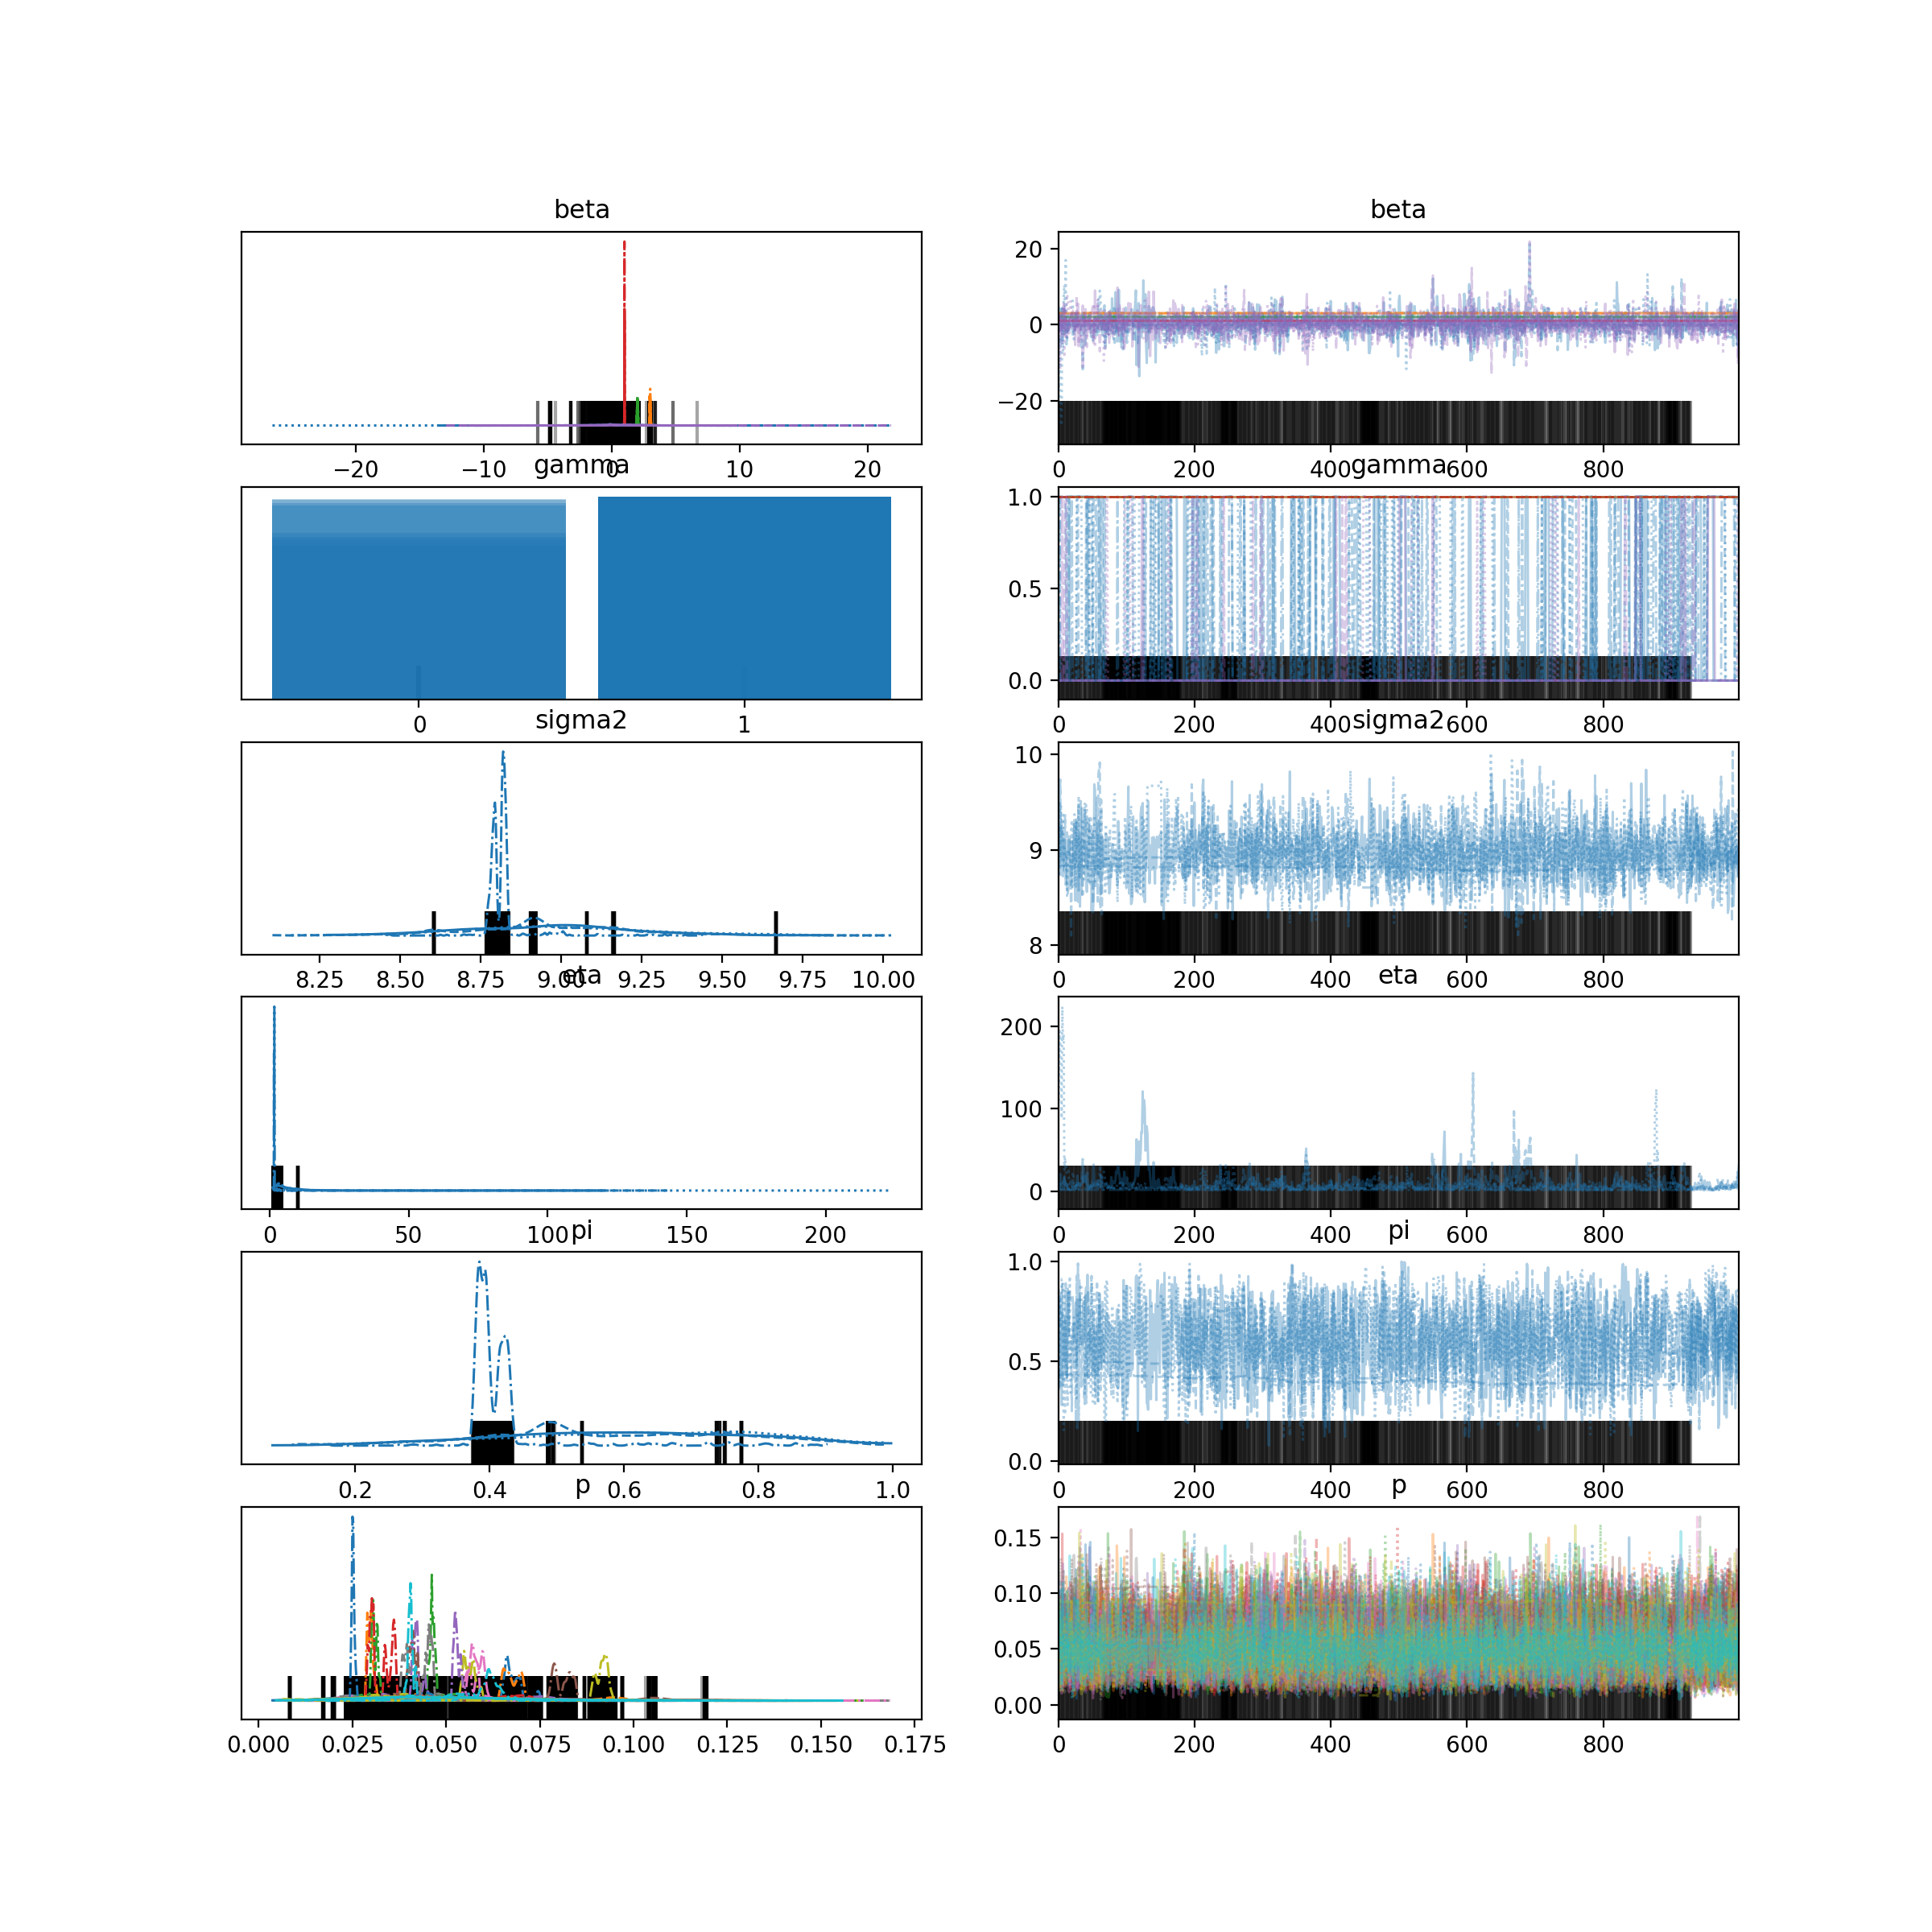

           mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]   0.305   2.319  -4.843    3.574      0.044    0.067    2611.0   
beta[1]   3.002   0.027   2.951    3.051      0.001    0.001     821.0   
beta[2]   2.009   0.034   1.942    2.068      0.002    0.001     410.0   
beta[3]   0.997   0.007   0.984    1.010      0.000    0.000     765.0   
beta[4]   0.375   2.317  -4.382    4.349      0.042    0.097    3202.0   
gamma[0]  0.208   0.406   0.000    1.000      0.018    0.013     485.0   
gamma[1]  1.000   0.000   1.000    1.000      0.000    0.000    4000.0   
gamma[2]  1.000   0.000   1.000    1.000      0.000    0.000    4000.0   
gamma[3]  1.000   0.000   1.000    1.000      0.000    0.000    4000.0   
gamma[4]  0.025   0.155   0.000    0.000      0.006    0.004     698.0   
sigma2    8.933   0.255   8.452    9.461      0.030    0.021      74.0   
eta       6.336  11.479   0.852   16.718      1.330    0.944      11.0   
pi        0.555   0.183   0.271    0.8

/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [33]:
az.plot_trace(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma", "sigma2", "eta", "pi", "p"])
print(summary)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [eta2, sigma2, pi, p, xi]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma]


Output()

Sampling 4 chains for 500 tune and 2_000 draw iterations (2_000 + 8_000 draws total) took 178 seconds.
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 644 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0] -0.019  0.051  -0.146    0.005      0.002    0.001    1042.0   
beta[1]  3.004  0.026   2.954    3.052      0.000    0.000    4675.0   
beta[2]  2.010  0.033   1.952    2.076      0.001    0.000    4071.0   
beta[3]  0.998  0.007   0.986    1.011      0.000    0.000    2910.0   
beta[4] -0.000  0.003   0.000   -0.000      0.000    0.000    2579.0   

         ess_tail  r_hat  
beta[0]     863.0   1.01  
beta[1]    5081.0   1.00  
beta[2]    1925.0   1.00  
beta[3]    1586.0   1.00  
beta[4]    1336.0   1.02  


<IPython.core.display.Javascript object>


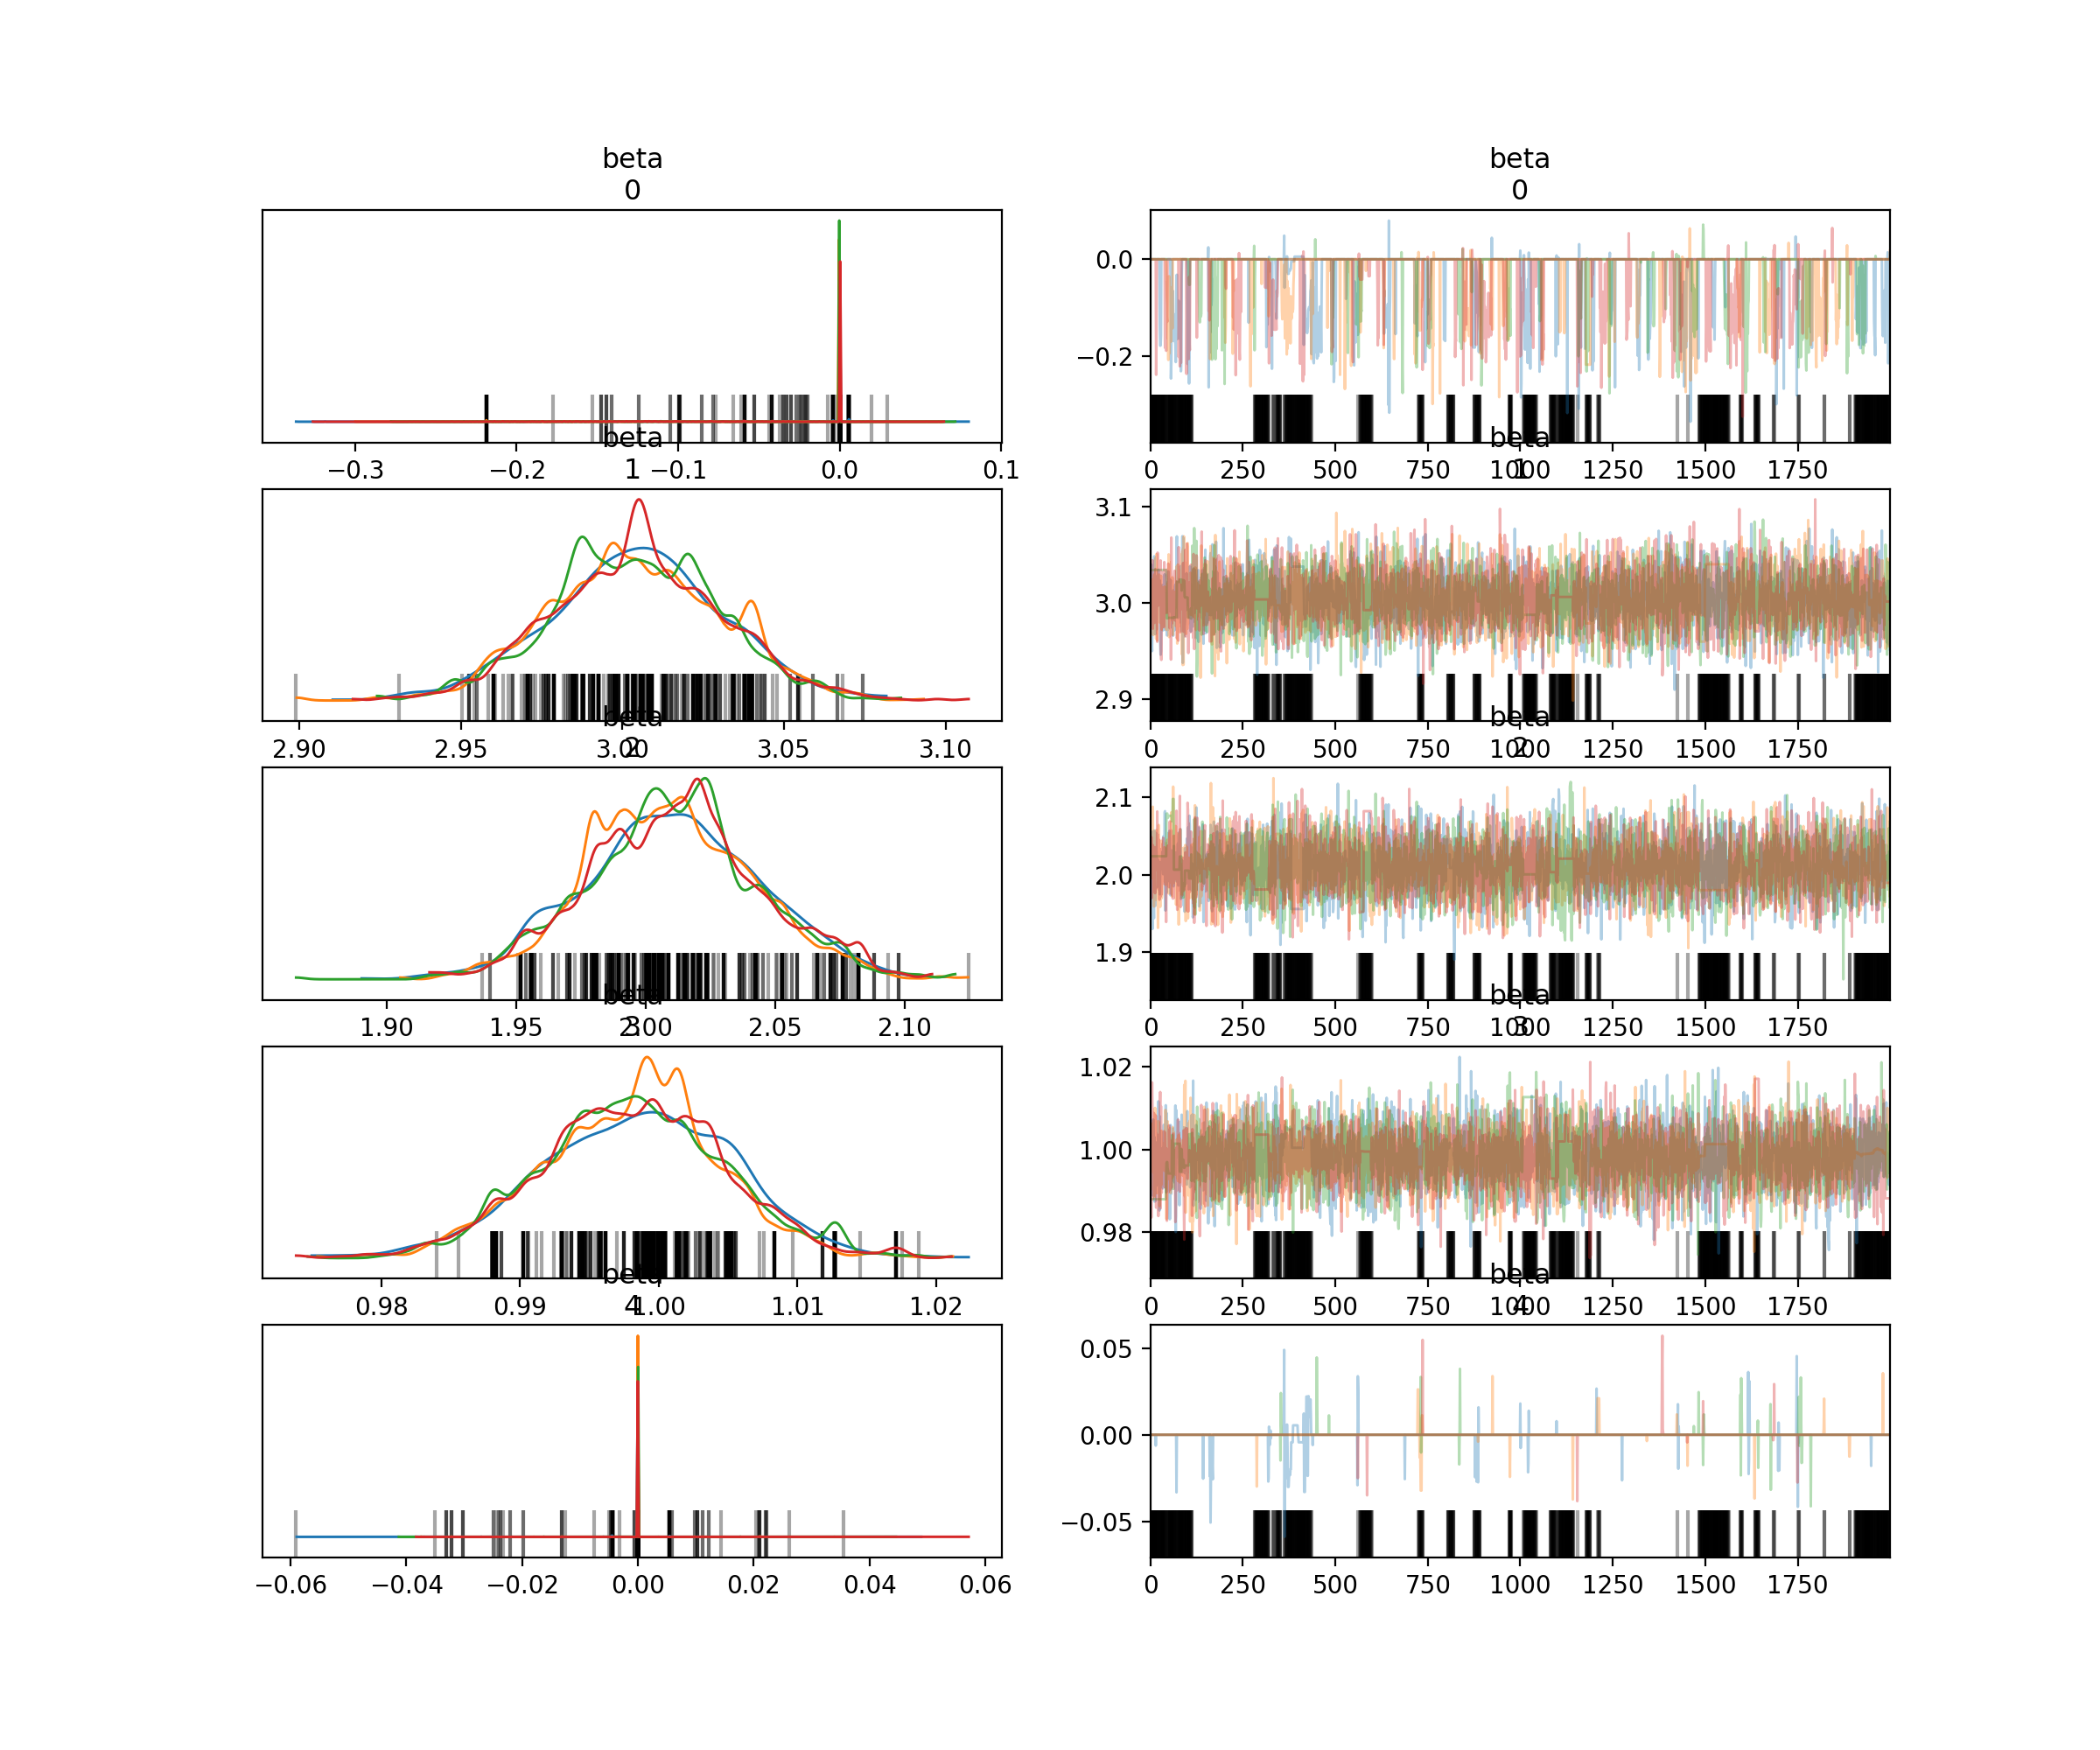

In [42]:

# Dirichlet prior concentration parameter
alpha = 25.0 

# Hyperparameters for data variance
a_sigma = 0.1
b_sigma = 0.1

# Hyperparameters for base distribution
a_eta = 0.1
b_eta = 0.1

# A suitably large number, for the number of possible values the coefficients can choose from
M = 20 

# Number of coefficients
K = 5


if __name__ == "__main__":
    with pm.Model() as model:
        eta2 = pm.InverseGamma("eta2", alpha=a_eta, beta=b_eta)
        sigma2 = pm.InverseGamma("sigma2", alpha=a_sigma, beta=b_sigma)

        pi = pm.Uniform("pi", lower=0.0, upper=1.0)

        # Class probabilities
        p = pm.Dirichlet("p", a=np.repeat(alpha/M, M), shape=M) 

        # Latent variables for constructing the coefficients
        xi = pm.Normal("xi", mu=0.0, sigma=pm.math.sqrt(eta2), shape=M)

        # Class assignment for predictors
        S = pm.Categorical("S", p=p, shape=K)

        # Sparsity indicator
        gamma = pm.Bernoulli("gamma", p=pi, shape=K)

        # Coefficients
        beta = pm.Deterministic("beta", gamma * xi[S]) 

        y_obs = pm.Normal("y_obs", mu=pm.math.dot(X_with_intercept, beta), sigma=pm.math.sqrt(sigma2), observed=y)

        # Sampling  
        trace = pm.sample(2000, tune=500, target_accept=0.95, return_inferencedata=True)
        summary = az.summary(trace, var_names=["beta"])  
        print(summary)
        az.plot_trace(trace, var_names=["beta"], compact=False)
        plt.show()

<IPython.core.display.Javascript object>


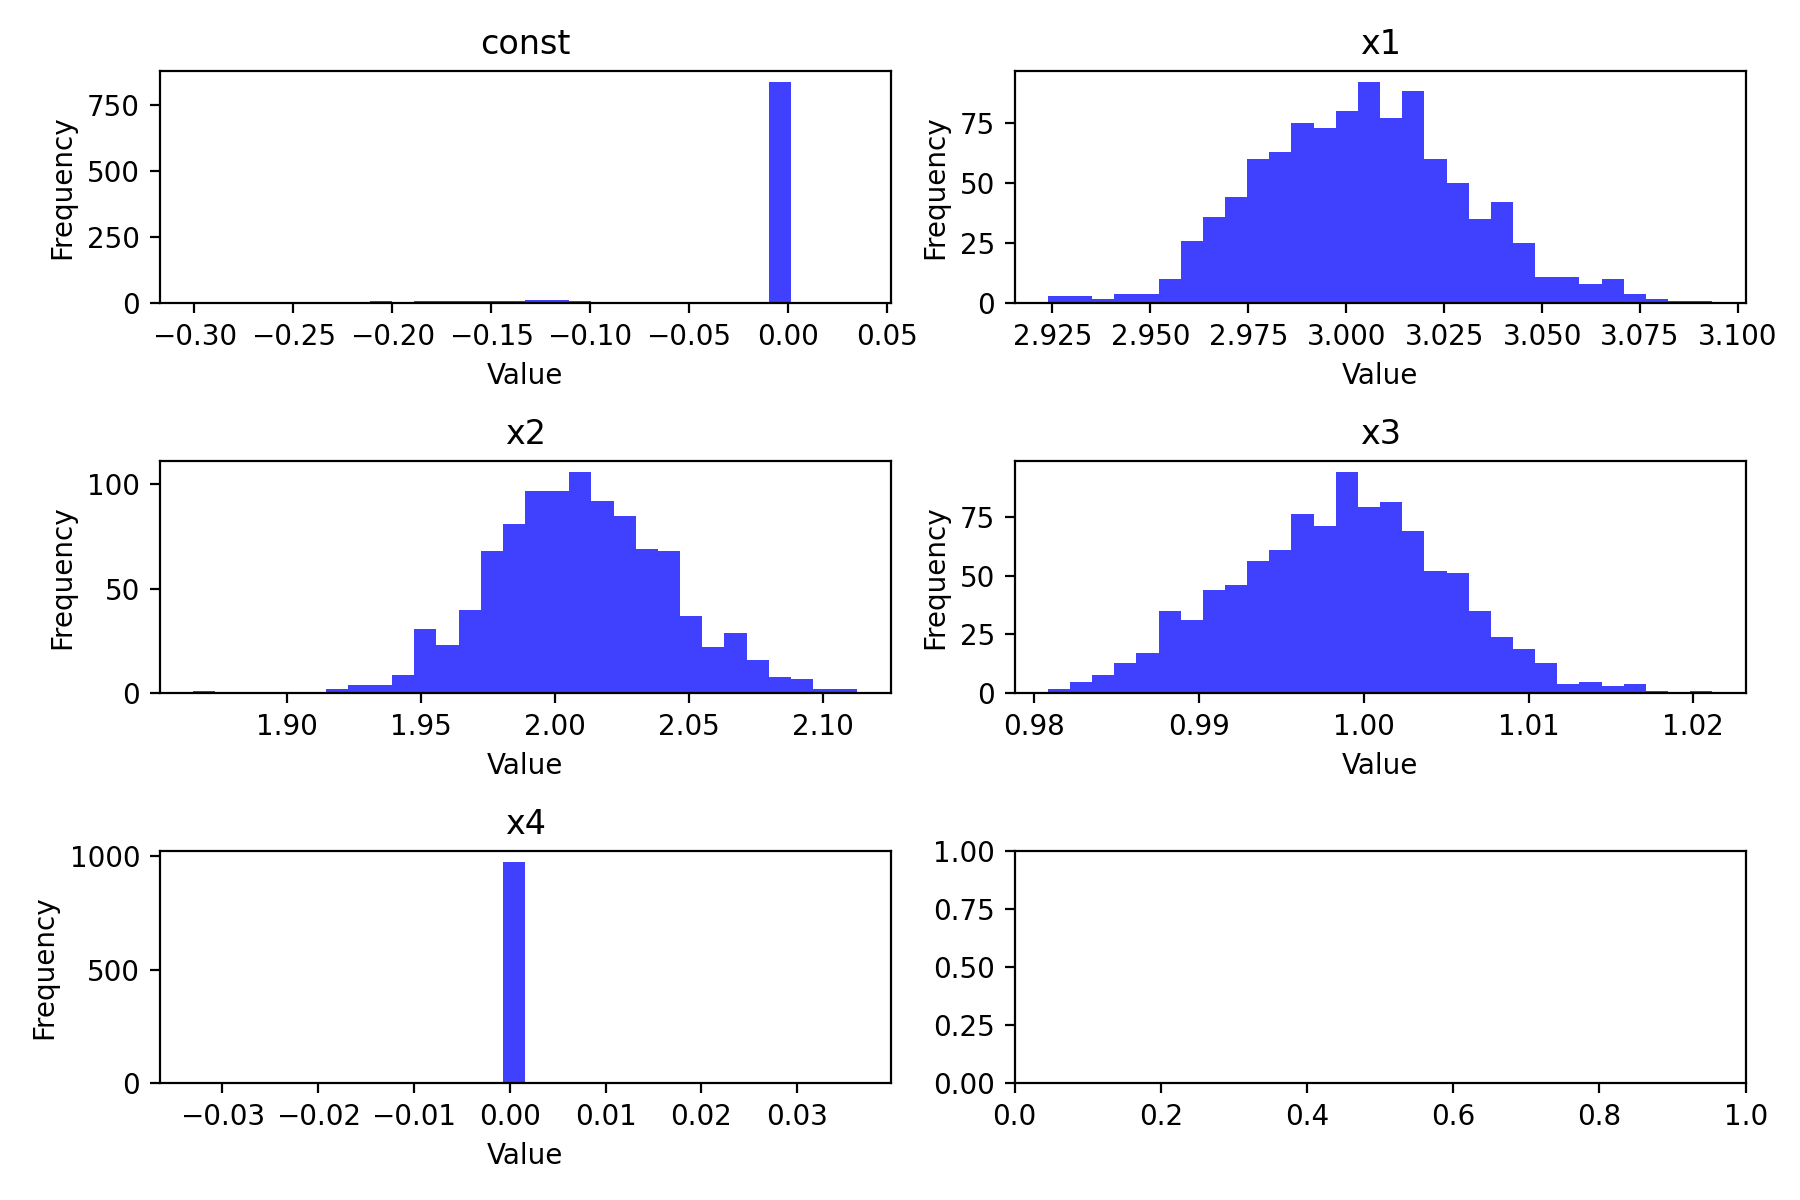

[0.166 1.    1.    1.    0.025]
[-2.00852316e-02  3.00411076e+00  2.00997392e+00  9.98562532e-01
  4.14067816e-05]
1000 samples' R² values=: 0.9485
1000 samples' RMSE values: 2.9921


In [52]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 6))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution_number1.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
#print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")
# 计算 RMSE
RMSE = np.sqrt(np.mean((pred_mean - y) ** 2))
print(f"1000 samples' RMSE values: {RMSE:.4f}")


<IPython.core.display.Javascript object>


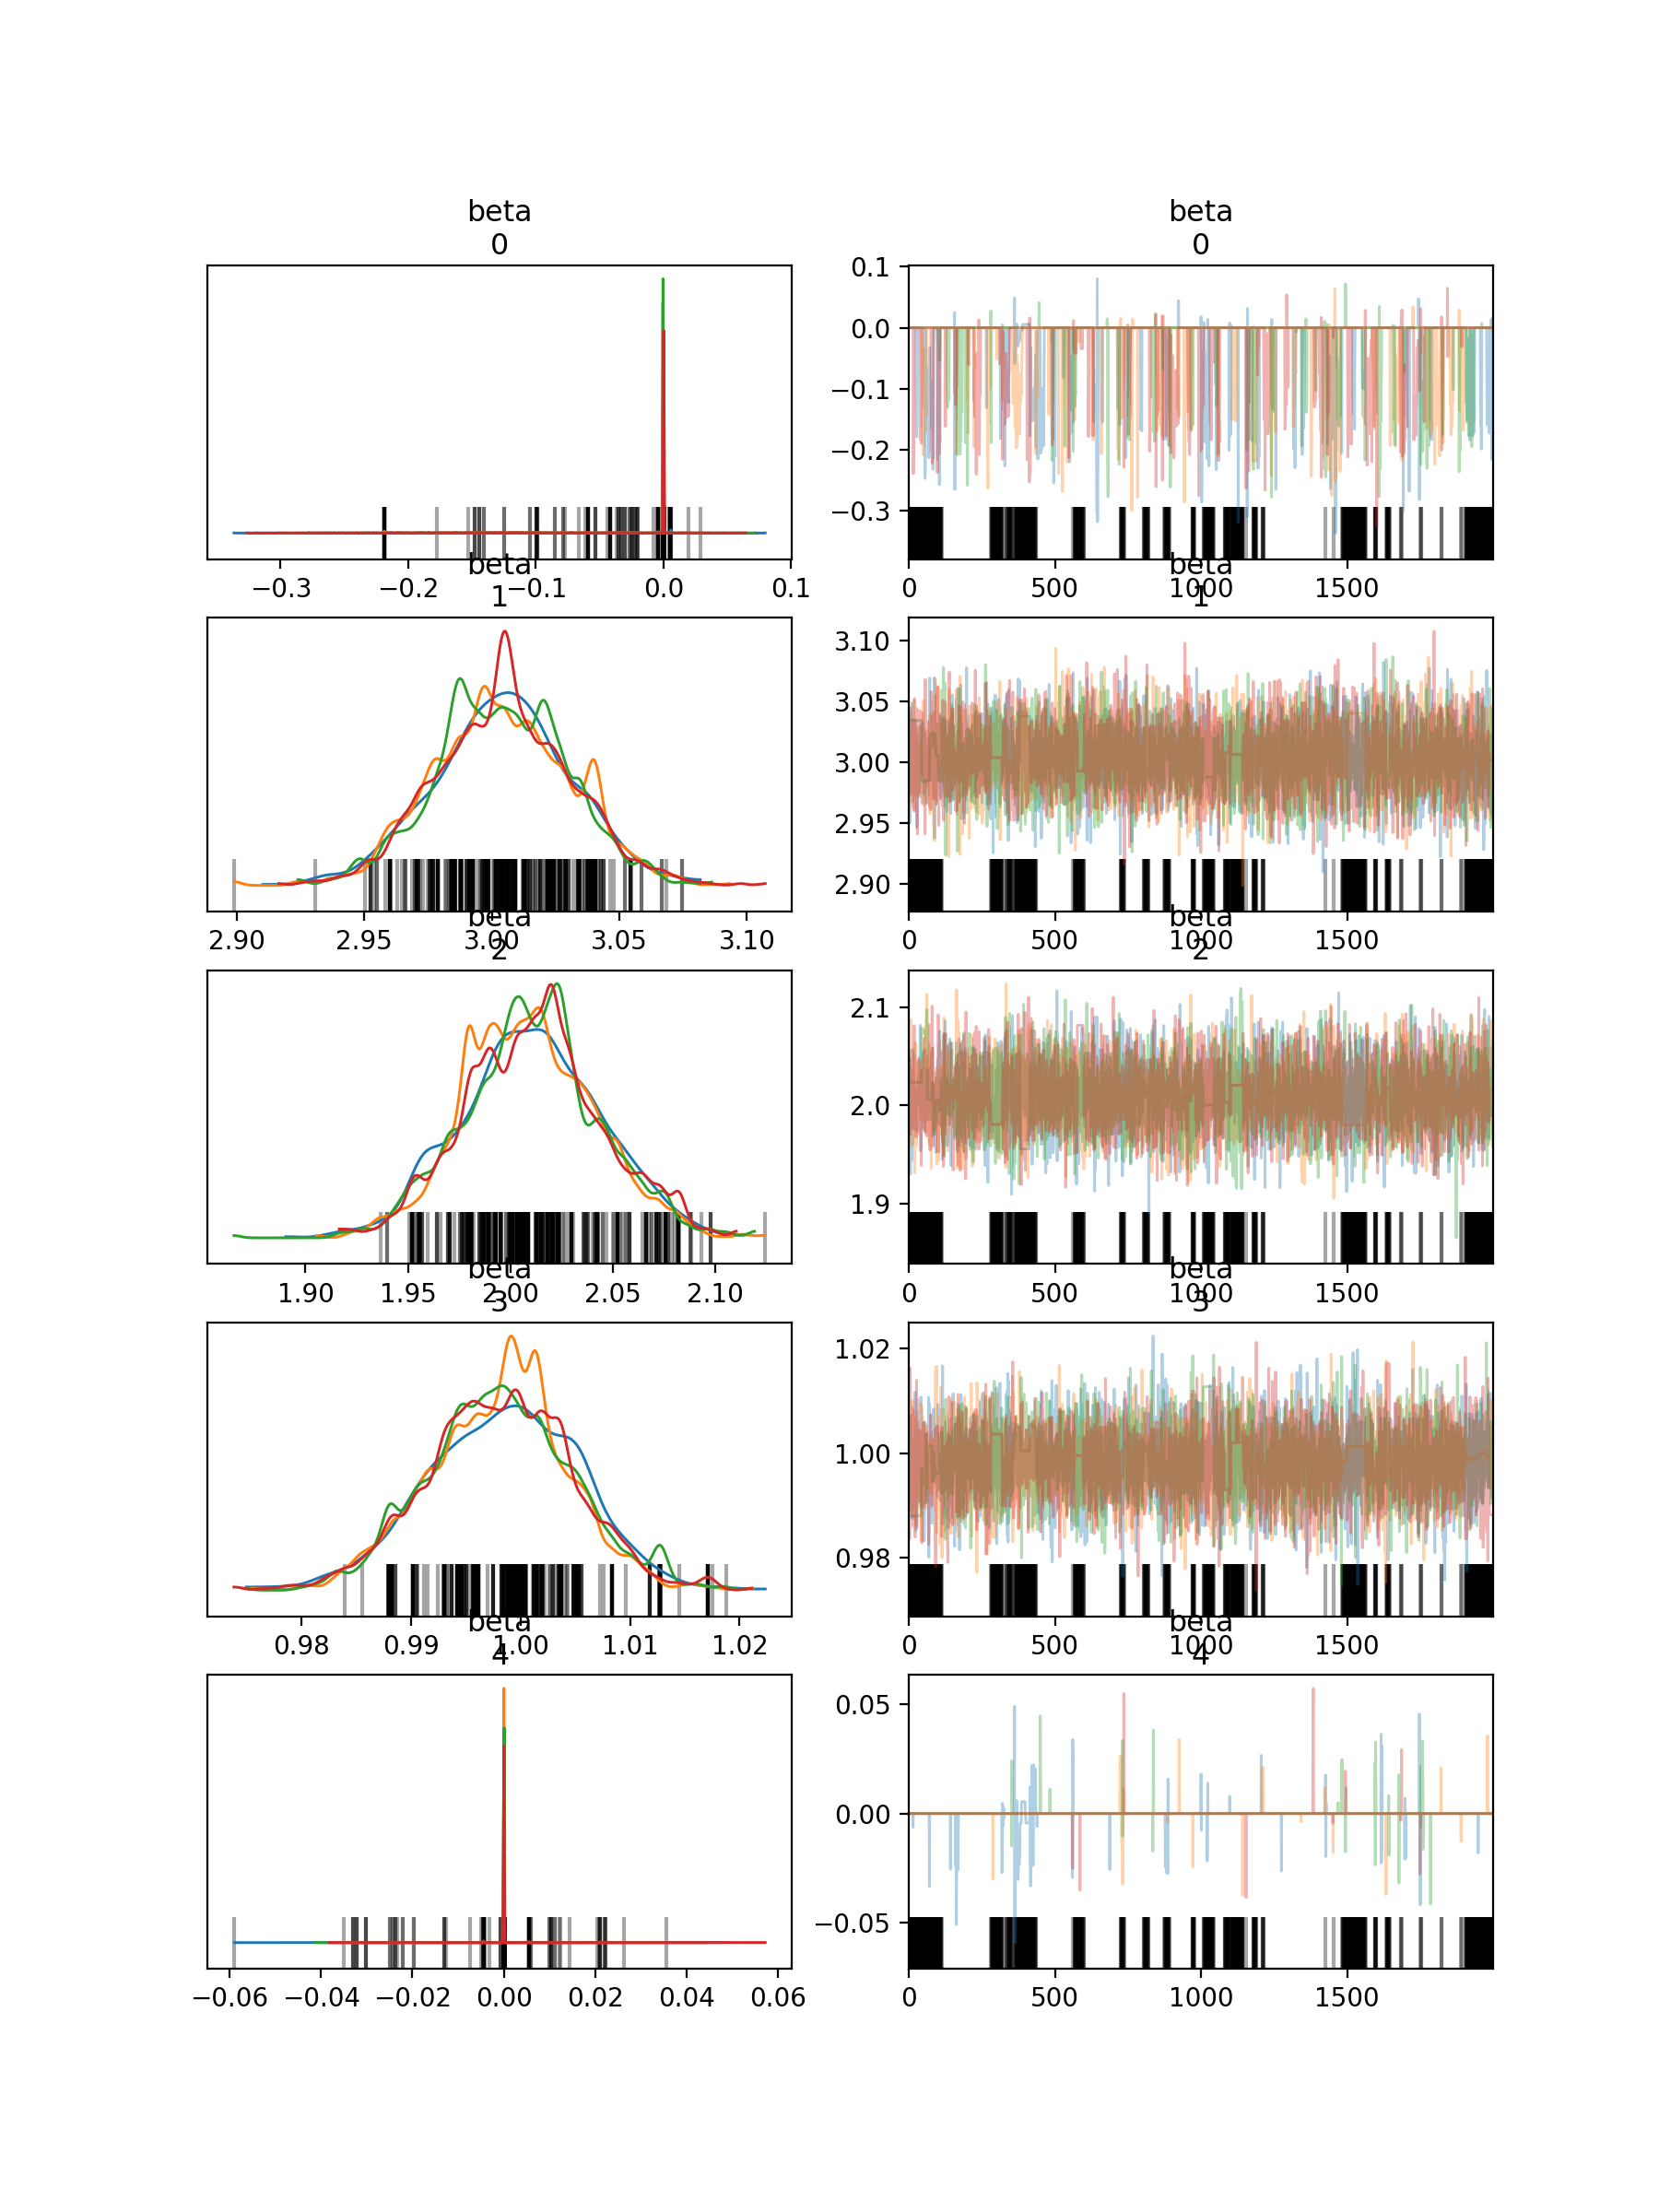

In [50]:
az.plot_trace(trace, var_names=["beta"],figsize=(9, 12), compact=False)
plt.show()

In [3]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

class BayesianCompositionalRegression:
    def __init__(self, n_features, n_covariates, n_categories):
        self.n_features = n_features
        self.n_covariates = n_covariates
        self.n_categories = n_categories
        self.setup_priors()

    def setup_priors(self):
        # 定义超参数
        self.a_psi = 1.0
        self.b_psi = 1.0
        self.kappa_a = 1.0  # Beta先验参数
        self.kappa_b = 1.0
        
        # 变分参数初始化
        self.theta_loc = pyro.param("theta_loc", torch.zeros(self.n_features))
        self.theta_scale = pyro.param("theta_scale", torch.ones(self.n_features), 
                                    constraint=dist.constraints.positive)
        self.xi_probs = pyro.param("xi_probs", 0.5 * torch.ones(self.n_features),
                                 constraint=dist.constraints.interval(0.0, 1.0))
        self.a_psi_post = pyro.param("a_psi_post", torch.tensor(2.0),
                                   constraint=dist.constraints.positive)
        self.b_psi_post = pyro.param("b_psi_post", torch.tensor(2.0),
                                   constraint=dist.constraints.positive)

    def model(self, Z, X, W, y):
        # Beta先验采样kappa
        kappa = pyro.sample("kappa", dist.Beta(self.kappa_a, self.kappa_b))
        
        # 组合参数θ的先验
        with pyro.plate("features", self.n_features):
            xi = pyro.sample("xi", dist.Bernoulli(kappa))  # 使用采样得到的kappa
            psi = pyro.sample("psi", dist.InverseGamma(self.a_psi, self.b_psi))
            theta = pyro.sample("theta", dist.Normal(0, torch.sqrt(psi * xi)))
        
        # 施加组合约束 sum(theta) = 0
        theta_centered = theta - theta.mean()
        
        # 其他协变量的先验
        beta = pyro.sample("beta", dist.Normal(0, 1))
        gamma = pyro.sample("gamma", dist.Normal(0, 1))
        
        # 线性预测
        linear_pred = (Z @ theta_centered) + (X @ beta) + (W @ gamma)
        
        # 观测噪声
        sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
        with pyro.plate("data", len(y)):
            pyro.sample("obs", dist.Normal(linear_pred, sigma), obs=y)

    def guide(self, Z, X, W, y):
        # 变分分布参数
        theta_loc = pyro.param("theta_loc")
        theta_scale = pyro.param("theta_scale")
        xi_probs = pyro.param("xi_probs")
        a_psi_post = pyro.param("a_psi_post")
        b_psi_post = pyro.param("b_psi_post")
        
        # kappa的变分后验（Beta分布）
        kappa_a_post = pyro.param("kappa_a_post", torch.tensor(1.0),
                                 constraint=dist.constraints.positive)
        kappa_b_post = pyro.param("kappa_b_post", torch.tensor(1.0),
                                 constraint=dist.constraints.positive)
        pyro.sample("kappa", dist.Beta(kappa_a_post, kappa_b_post))
        
        # 特征选择参数的变分分布
        with pyro.plate("features", self.n_features):
            pyro.sample("xi", dist.Bernoulli(xi_probs))
            pyro.sample("psi", dist.InverseGamma(a_psi_post, b_psi_post))
            pyro.sample("theta", dist.Normal(theta_loc, theta_scale))
        
        # 其他参数的变分分布
        beta_loc = pyro.param("beta_loc", torch.zeros(self.n_covariates))
        pyro.sample("beta", dist.Normal(beta_loc, torch.ones(self.n_covariates)))
        
        gamma_loc = pyro.param("gamma_loc", torch.zeros(self.n_categories))
        pyro.sample("gamma", dist.Normal(gamma_loc, torch.ones(self.n_categories)))

    def fit(self, Z, X, W, y, num_epochs=1000):
        optim = Adam({"lr": 0.01})
        svi = SVI(self.model, self.guide, optim, loss=Trace_ELBO())
        
        for epoch in range(num_epochs):
            loss = svi.step(Z, X, W, y)
            if epoch % 100 == 0:
                print(f"Epoch {epoch} Loss: {loss}")

    def predict(self, Z_new, X_new, W_new, num_samples=100):
        predictive = pyro.infer.Predictive(self.model, guide=self.guide, num_samples=num_samples)
        samples = predictive(Z_new, X_new, W_new, None)
        return samples["obs"].mean(0)

# 示例用法
if __name__ == "__main__":
    # 模拟数据
    n = 100
    d = 50
    Z = torch.randn(n, d)
    X = torch.randn(n, 3)
    W = torch.randn(n, 2)
    y = torch.randn(n)
    
    model = BayesianCompositionalRegression(n_features=d, n_covariates=3, n_categories=2)
    model.fit(Z, X, W, y)
    
    predictions = model.predict(Z[:5], X[:5], W[:5])
    print("Predictions:", predictions)

ValueError: Expected parameter scale (Tensor of shape (50,)) of distribution Normal(loc: torch.Size([50]), scale: torch.Size([50])) to satisfy the constraint GreaterThan(lower_bound=0.0), but found invalid values:
tensor([0.8618, 0.0000, 0.8084, 0.0000, 0.0000, 2.1160, 2.2373, 0.9607, 1.1747,
        0.0000, 1.9104, 1.0480, 0.0000, 0.0000, 1.7710, 0.9312, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0605, 0.0000, 0.7728, 1.0110, 1.5240, 0.0000, 1.4481,
        2.2547, 0.0000, 0.0000, 0.8393, 0.0000, 0.0000, 0.0000, 1.0169, 4.7841,
        1.0144, 0.9599, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.9808,
        1.1389, 0.0000, 0.9932, 0.8304, 0.0000], grad_fn=<SqrtBackward0>)
Trace Shapes:     
 Param Sites:     
Sample Sites:     
   kappa dist    |
        value    |
features dist    |
        value 50 |
      xi dist 50 |
        value 50 |
     psi dist 50 |
        value 50 |